#  Concluzii & Error Analysis

## Structura:
1. Error Analysis — analiza erorilor modelului câștigător
2. Concluzii finale
3. Recomandări pentru industrie

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/movies_clean.csv')

features = ['budget', 'vote_average', 'vote_count',
            'popularity', 'runtime', 'release_year', 'release_month']

X = df[features]
y = df['disappointment_index']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
y_pred = gb.predict(X_test)



## 1. Error Analysis
Analizăm erorile modelului câștigător — Gradient Boosting.

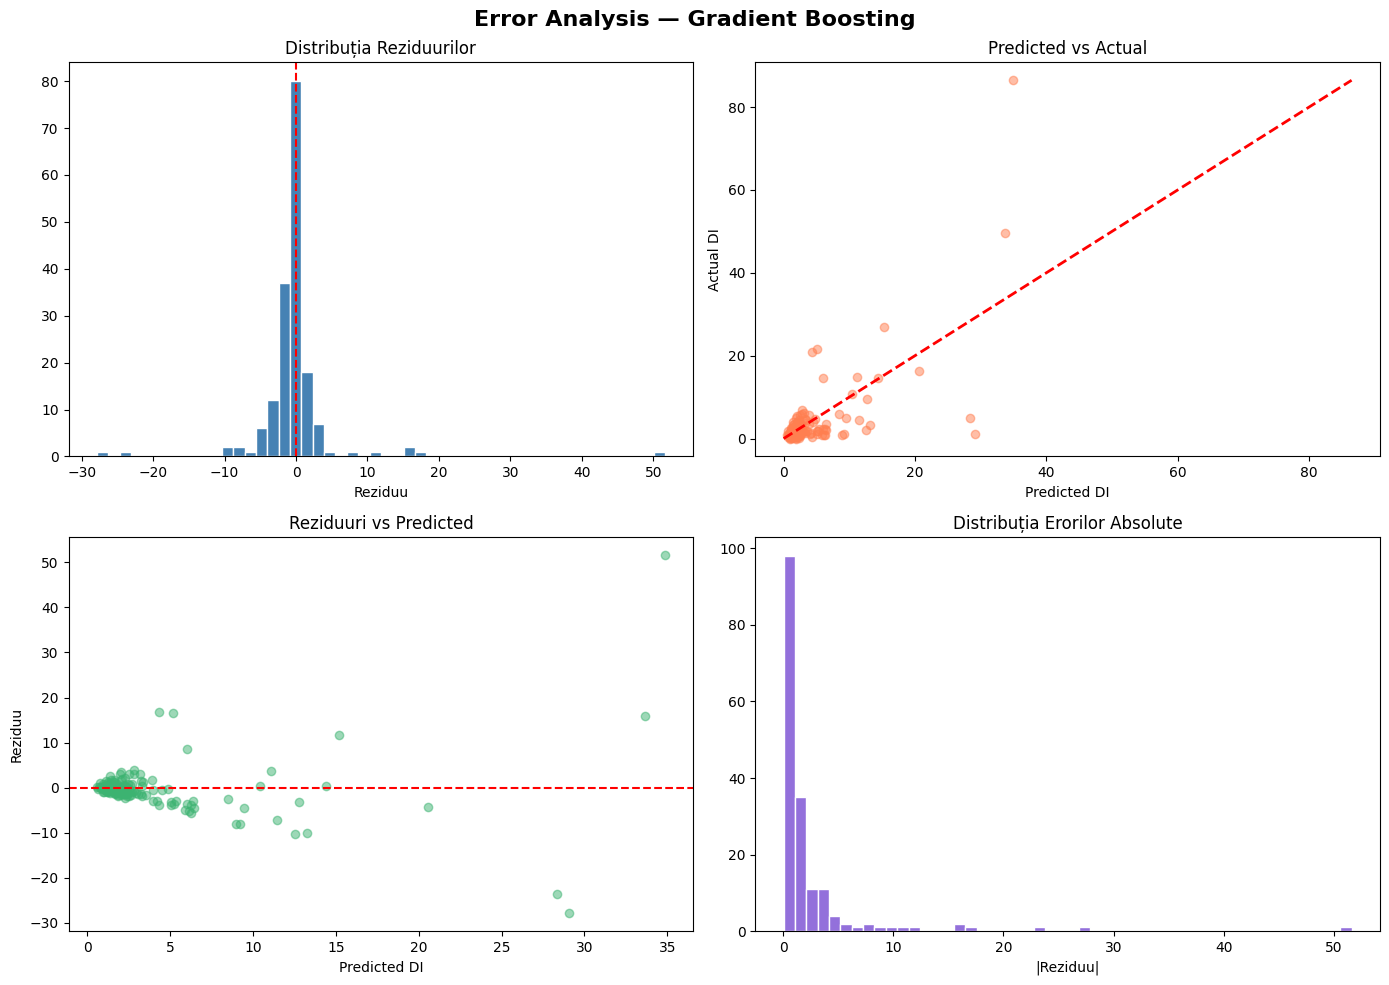

Medie reziduuri: -0.3277
Std reziduuri: 5.8180
Max eroare: 51.6156


In [3]:
# Calculăm reziduurile
residuals = y_test - y_pred

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Error Analysis — Gradient Boosting', 
             fontsize=16, fontweight='bold')

# Distribuția erorilor
axes[0,0].hist(residuals, bins=50, color='steelblue', edgecolor='white')
axes[0,0].axvline(x=0, color='red', linestyle='--')
axes[0,0].set_title('Distribuția Reziduurilor')
axes[0,0].set_xlabel('Reziduu')

# Predicted vs Actual
axes[0,1].scatter(y_pred, y_test, alpha=0.5, color='coral')
axes[0,1].plot([0, y_test.max()], [0, y_test.max()], 
               'r--', linewidth=2)
axes[0,1].set_title('Predicted vs Actual')
axes[0,1].set_xlabel('Predicted DI')
axes[0,1].set_ylabel('Actual DI')

# Reziduuri vs Predicted
axes[1,0].scatter(y_pred, residuals, alpha=0.5, color='mediumseagreen')
axes[1,0].axhline(y=0, color='red', linestyle='--')
axes[1,0].set_title('Reziduuri vs Predicted')
axes[1,0].set_xlabel('Predicted DI')
axes[1,0].set_ylabel('Reziduu')

# Distribuția erorilor absolute
axes[1,1].hist(abs(residuals), bins=50, 
               color='mediumpurple', edgecolor='white')
axes[1,1].set_title('Distribuția Erorilor Absolute')
axes[1,1].set_xlabel('|Reziduu|')

plt.tight_layout()
plt.savefig('../data/error_analysis.png', dpi=150)
plt.show()

print(f"Medie reziduuri: {residuals.mean():.4f}")
print(f"Std reziduuri: {residuals.std():.4f}")
print(f"Max eroare: {abs(residuals).max():.4f}")


**Distribuția Reziduurilor:**
- Centrată în jurul lui 0 → modelul nu e sistematic biased
- Ușor asimetrică spre dreapta → subestimăm câteva surprize pozitive uriașe
- Medie reziduuri: -0.33 → aproape 0, foarte bine!

**Predicted vs Actual:**
- Punctele urmează linia diagonală → modelul prezice corect tendința
- Dispersie mare la valori mari de DI → filmele cu surprize 
  uriașe sunt greu de prezis

**Reziduuri vs Predicted:**
- Fără pattern clar → modelul nu are bias sistematic
- Câteva outliere extreme (DI > 40) → blockbustere neprevăzute

**Erori Absolute:**
- Majoritatea erorilor sunt sub 5 → predicții bune
- Max eroare = 51.6 → un film extrem de surprinzător

> **Concluzie:** Modelul funcționează bine pentru filme 
> obișnuite dar subestimează blockbusterele excepționale — 


In [6]:

# FILMELE CEL MAI GREȘIT PREZISE

df_test = X_test.copy()
df_test['actual_di'] = y_test.values
df_test['predicted_di'] = y_pred
df_test['error'] = abs(df_test['actual_di'] - df_test['predicted_di'])
df_test['title'] = df.loc[X_test.index, 'title'].values

print(" Top 10 filme cel mai greșit prezise:")
print(df_test.nlargest(10, 'error')[
    ['title', 'actual_di', 'predicted_di', 'error']
].to_string(index=False))

 Top 10 filme cel mai greșit prezise:
                          title  actual_di  predicted_di     error
                      Halloween  86.474581     34.858992 51.615589
          It's a Wonderful Life   1.213097     29.068282 27.855185
               The Wizard of Oz   4.862077     28.334232 23.472156
                  Seven Samurai  21.000000      4.296033 16.703967
                     Your Name.  21.617074      5.139770 16.477304
Snow White and the Seven Dwarfs  49.697025     33.684952 16.012073
                           Jaws  26.894457     15.209738 11.684719
                       Superman   2.185298     12.539790 10.354492
          The Godfather Part II   3.156923     13.227613 10.070690
One Flew Over the Cuckoo's Nest  14.530837      6.000541  8.530296


### De ce greșește modelul la aceste filme?

Toate filmele din top 10 sunt **clasici legendari** — și asta nu e o coincidență.

**Halloween (eroare = 51.6)**
Produs cu un budget de doar 300.000$ în 1978, a generat 
venituri de 70 milioane$. Modelul nu poate anticipa că un 
film de groază low-budget va deveni fondatorul unui gen întreg.

**It's a Wonderful Life (eroare = 27.8)**
La lansare în 1946 a fost considerat un eșec comercial.
A devenit cult abia după decenii — modelul judecă pe baza 
datelor din momentul lansării, nu al posterității.

**The Wizard of Oz & clasicii**
Filme din era pre-televiziune cu reguli complet diferite 
ale industriei — modelul antrenat pe date moderne 
nu poate extraola corect la contexte istorice diferite.

**Jaws (eroare = 11.7)**
Primul blockbuster modern din istorie — a inventat 
conceptul de film de vară. Prin definiție, 
un eveniment unic nu poate fi prezis.

> **Concluzia cheie:**
> Modelul greșește tocmai la filmele care au **schimbat regulile jocului**.
> Inovația autentică și capodoperele sunt prin natura lor impredictibile.


## 2. Concluzii Finale

### De ce am făcut tot acest efort?

Am vrut să înțelegem un paradox real al industriei filmului:
de ce filme cu bugete de sute de milioane de dolari eșuează,
în timp ce filme făcute cu resurse minime devin legendare?

Am construit un **Disappointment Index** — o metrică originală
care măsoară discrepanța dintre ce merita un film să câștige
și ce a câștigat în realitate. Apoi am încercat să prezicăm
această metrică folosind date reale din TMDB.

---

### Ce am făcut concret:

**1. Am colectat și curățat 866 filme** cu date financiare
complete — bugete, venituri, ratinguri, popularitate, an de lansare.

**2. Am explorat datele** și am descoperit că distribuțiile
sunt puternic asimetrice — câteva blockbustere uriașe
distorsionează toată piața.

**3. Am estimat 5 modele** — de la regresia liniară OLS
până la Gradient Boosting — și le-am comparat sistematic.

**4. Am analizat erorile** și am descoperit că modelul
greșește cel mai mult tocmai la filmele legendare.

---

### Ce am învățat:

- **Bugetul mare crește riscul de dezamăgire** — corelație
  negativă confirmată în toate modelele
- **Anul lansării e cel mai important factor** — industria
  devine tot mai impredictibilă
- **Regresia liniară nu e suficientă** — R² = 0.19 vs
  R² = 0.49 la Gradient Boosting confirmă că relația e neliniară
- **50% rămâne neexplicat** — noroc, context cultural,
  timing — factori pe care niciun model nu îi poate cuantifica

---

### Concluzia principală:

> Succesul unui film nu urmează o formulă.
> Datele ne ajută să evităm greșelile evidente —
> dar nu pot prezice magia.
> Iar jumătatea pe care modelul n-o explică
> este exact partea care merită văzută pe marele ecran.